<a href="https://colab.research.google.com/github/anjali-28-main/Language_translator/blob/main/Copy_of_ecommerce_sales_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib seaborn numpy openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

os.makedirs("output", exist_ok=True)

In [ ]:
df = pd.read_csv("Ecommerce_Transactions_Data.csv")

df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials


In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (488501, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488501 entries, 0 to 488500
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  488501 non-null  object 
 1   Date           488501 non-null  object 
 2   ProductNo      488501 non-null  int64  
 3   Product        488501 non-null  object 
 4   Price          488501 non-null  float64
 5   Quantity       488501 non-null  int64  
 6   CustomerNo     483650 non-null  float64
 7   Country        488500 non-null  object 
 8   Category       488500 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 33.5+ MB


,0
TransactionNo,0
Date,0
ProductNo,0
Product,0
Price,0
Quantity,0
CustomerNo,4851
Country,1
Category,1


In [ ]:
df = df.drop_duplicates()

df = df.dropna()

df = df[~df["TransactionNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Revenue"] = df["Price"] * df["Quantity"]

df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category,Revenue
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience,110.00
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials,127.92
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study,172.50
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials,463.71
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials,39.96


In [ ]:
print("Total Revenue:", df["Revenue"].sum())

print("Orders:", df["TransactionNo"].nunique())

print("Customers:", df["CustomerNo"].nunique())

print("Average Order Value:", df["Revenue"].mean())

print("Top Country:", df["Country"].mode()[0])

print("Top Category:", df["Category"].mode()[0])

Total Revenue: 107556025.25999999
Orders: 365997
Customers: 89503
Average Order Value: 229.25624373337425
Top Country: Sweden
Top Category: Office & Study


Distribution of Transaction Amount

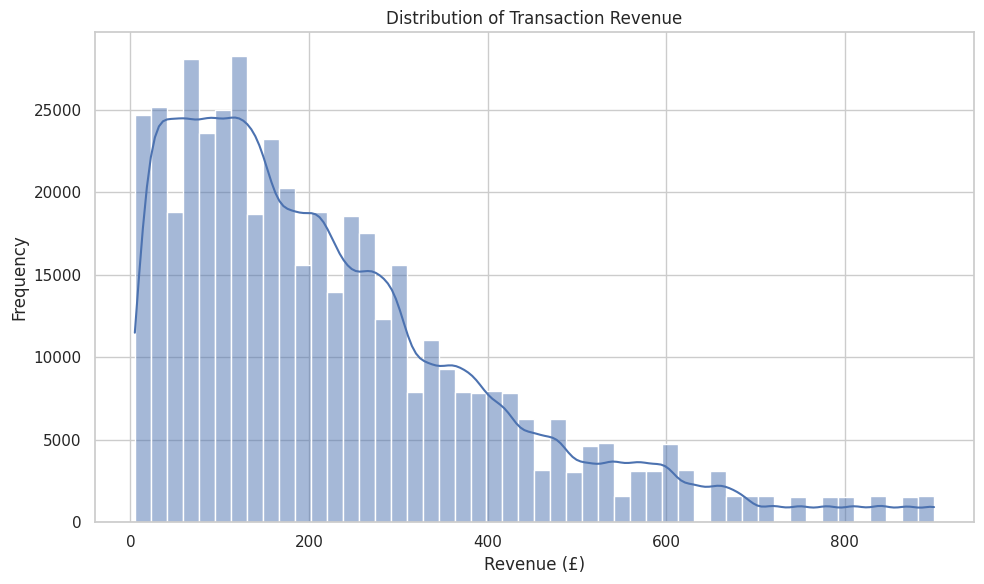

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["Revenue"], bins=50, kde=True)

plt.title("Distribution of Transaction Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("output/distribution_transaction_amount.png")

plt.show()

Revenue over time

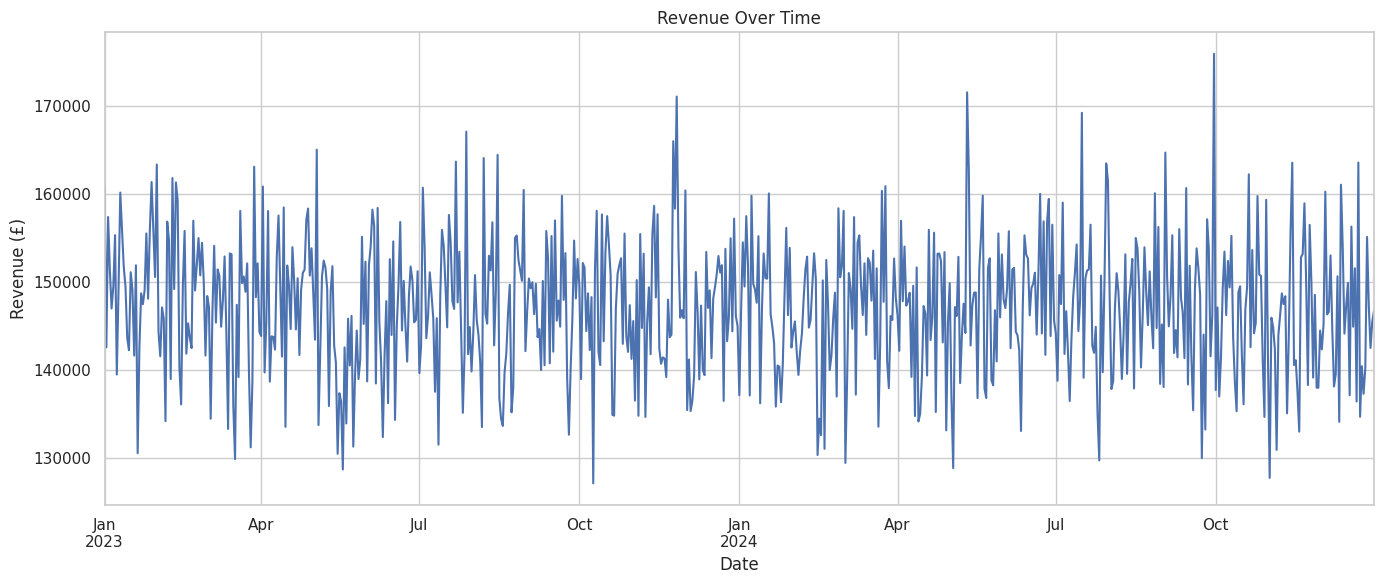

In [ ]:
daily_sales = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(14,6))

daily_sales.plot()

plt.title("Revenue Over Time")

plt.xlabel("Date")

plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.savefig("output/revenue_over_time.png")

plt.show()

Revenue by category

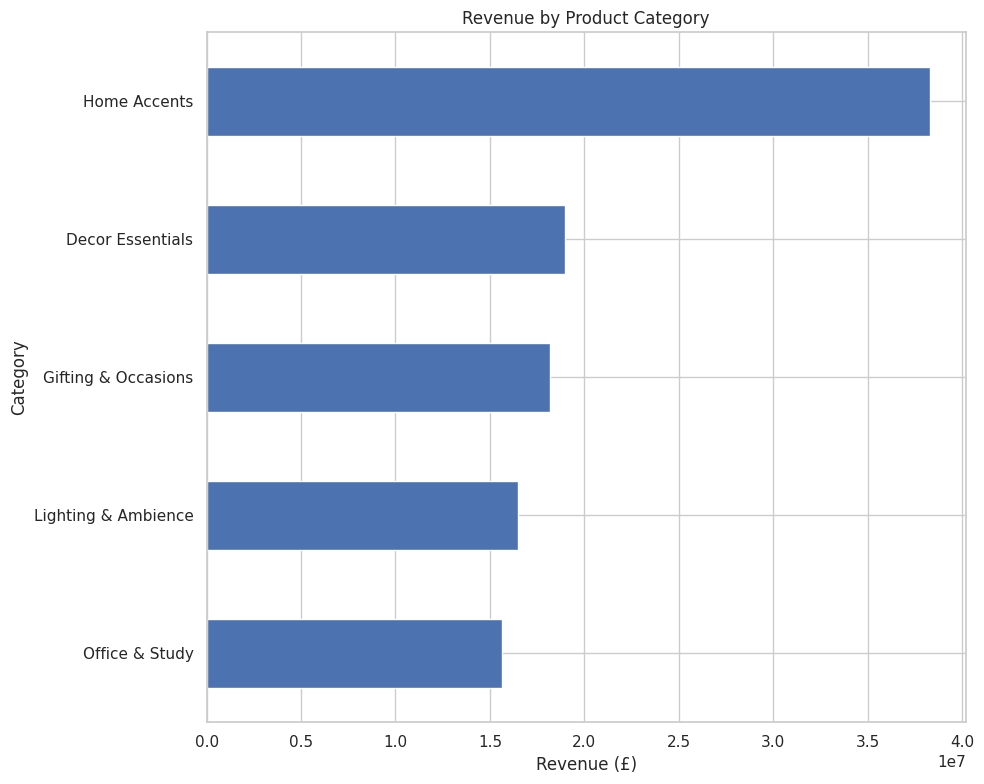

In [ ]:
category = df.groupby("Category")["Revenue"].sum().sort_values()

plt.figure(figsize=(10,8))

category.plot(kind="barh")

plt.title("Revenue by Product Category")

plt.xlabel("Revenue (£)")

plt.tight_layout()

plt.savefig("output/revenue_by_category.png")

plt.show()

Monthly Revenue Trend

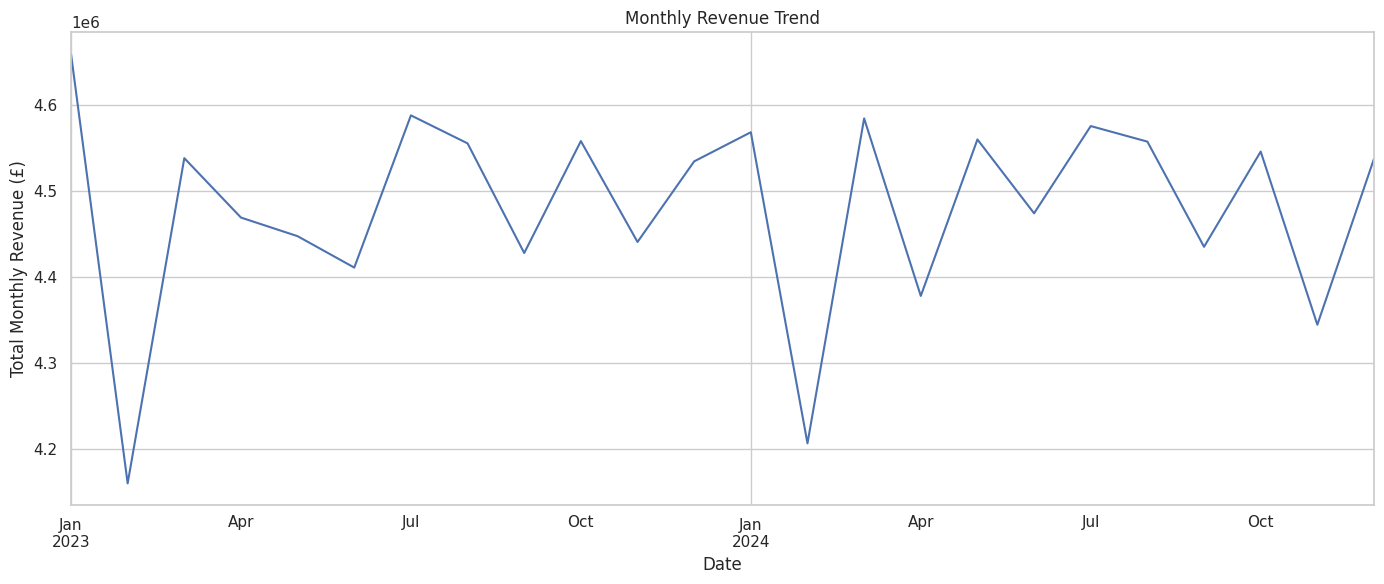

In [ ]:
monthly_revenue = df.set_index('Date').resample('M')['Revenue'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Monthly Revenue (£)')
plt.grid(True)
plt.tight_layout()
plt.savefig('output/monthly_revenue_trend.png')
plt.show()

Monthly Orders

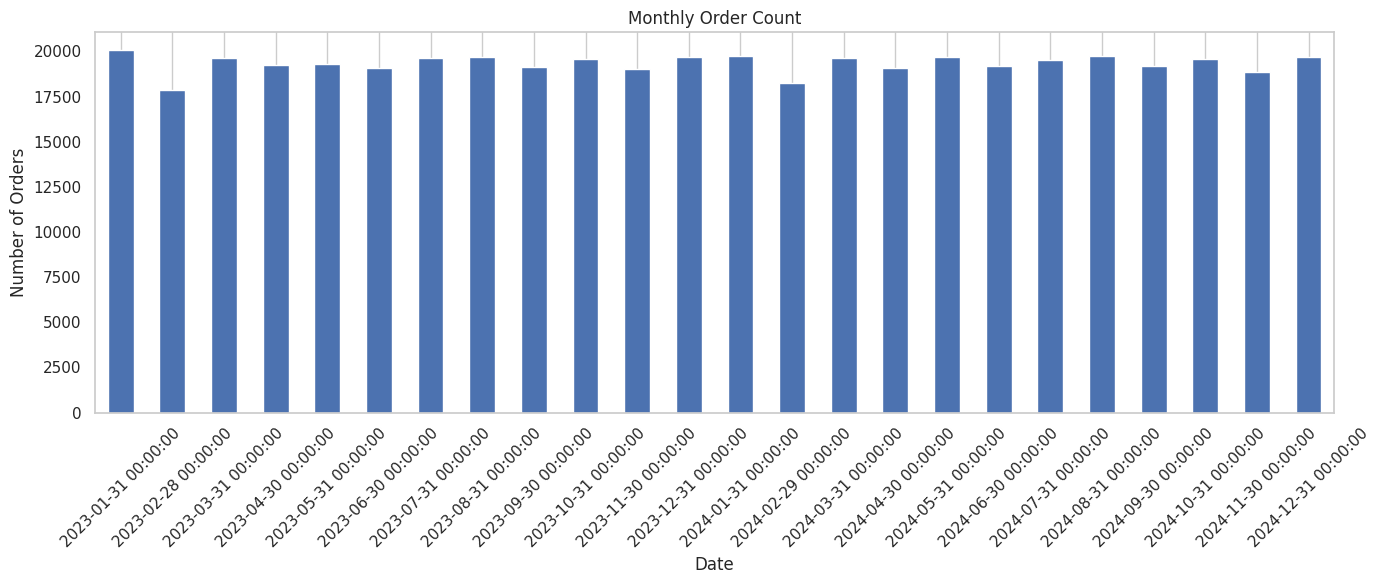

In [ ]:
monthly_orders = df.set_index('Date').resample('M')['TransactionNo'].nunique()

plt.figure(figsize=(14, 6))
monthly_orders.plot(kind='bar')
plt.title('Monthly Order Count')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('output/monthly_order_count.png')
plt.show()

Top Customers

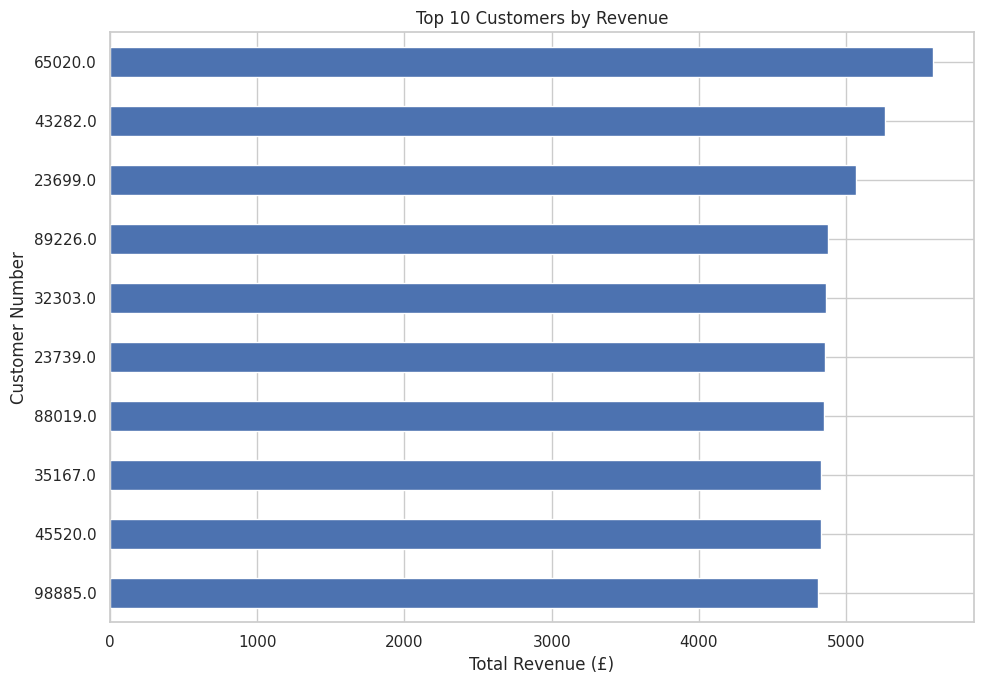

In [ ]:
top_customers = df.groupby('CustomerNo')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 7))
top_customers.sort_values().plot(kind='barh')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer Number')
plt.tight_layout()
plt.savefig('output/top_10_customers_by_revenue.png')
plt.show()

Repeat Purchase Distribution

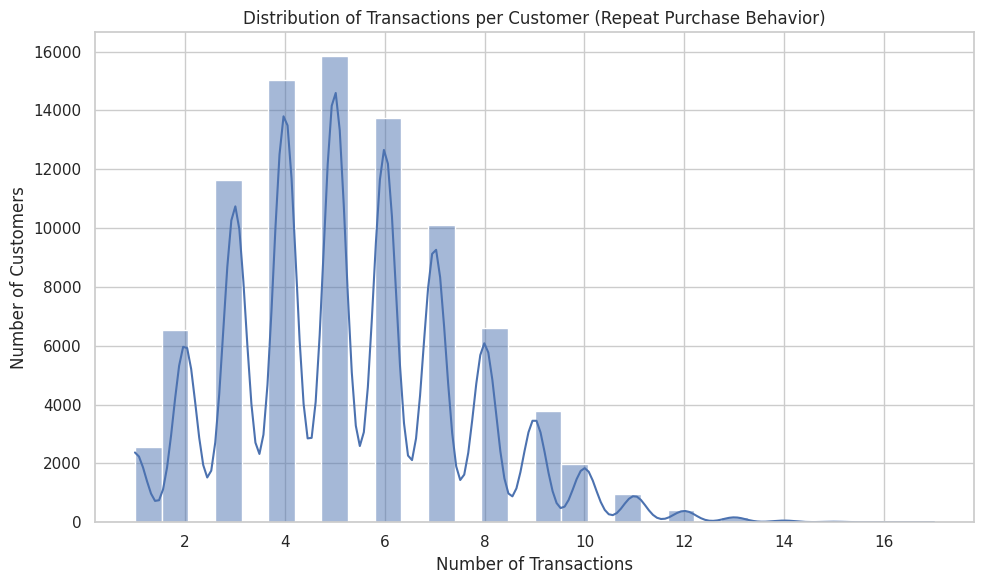

In [ ]:
transactions_per_customer = df.groupby('CustomerNo')['TransactionNo'].nunique()

plt.figure(figsize=(10, 6))
sns.histplot(transactions_per_customer, bins=30, kde=True)
plt.title('Distribution of Transactions per Customer (Repeat Purchase Behavior)')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.tight_layout()
plt.savefig('output/repeat_purchase_distribution.png')
plt.show()

Top Countries

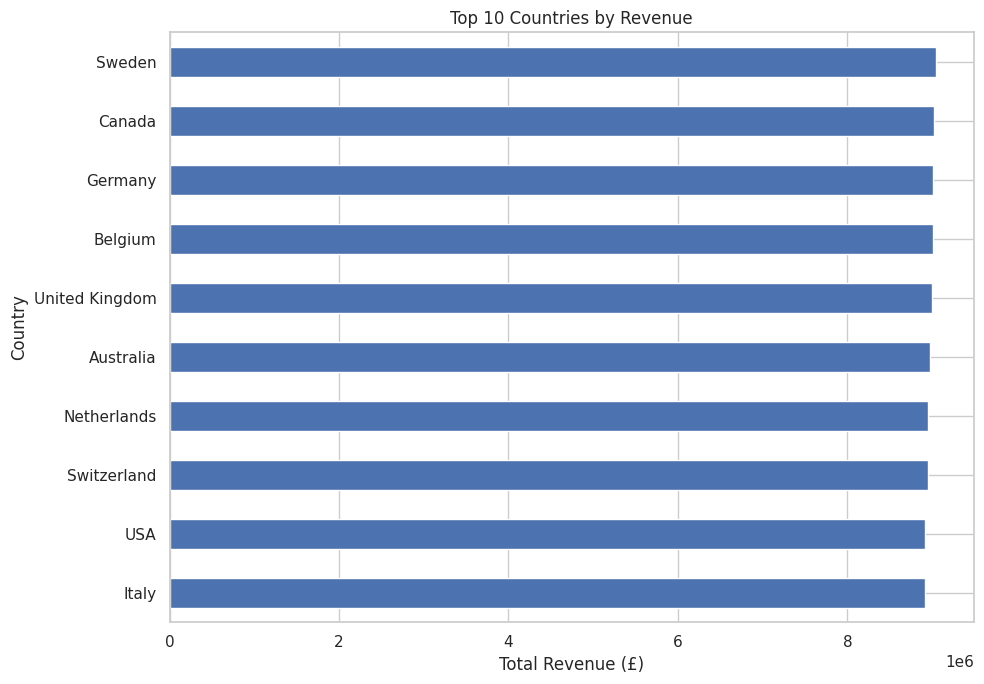

In [ ]:
top_countries = df.groupby('Country')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 7))
top_countries.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('output/top_10_countries_by_revenue.png')
plt.show()

Top Products

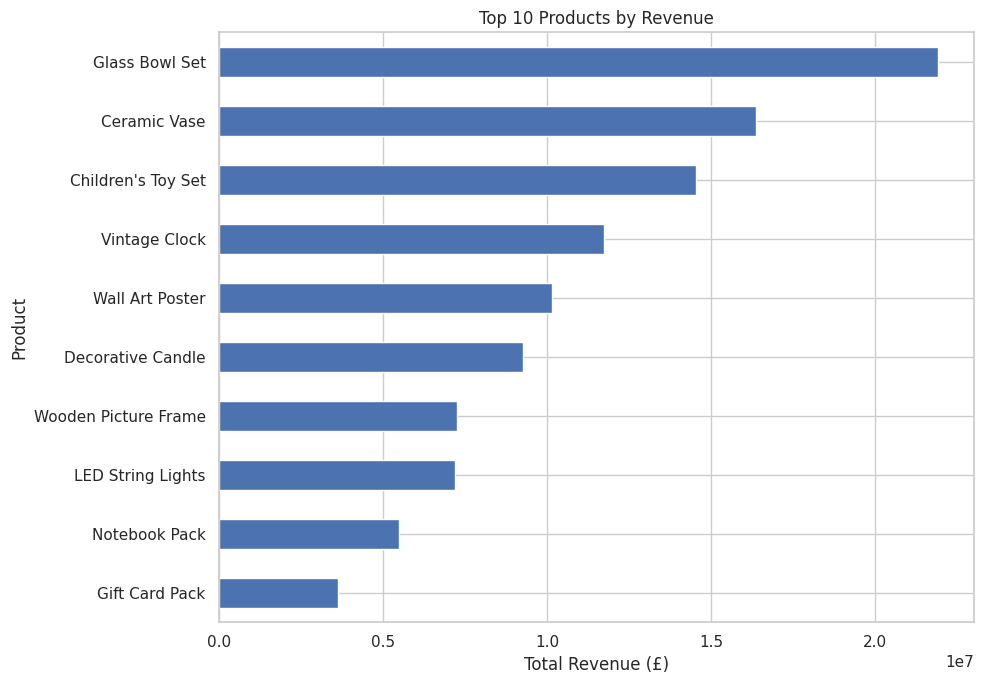

In [ ]:
top_products = df.groupby('Product')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 7))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('output/top_10_products_by_revenue.png')
plt.show()

Correlation heatmap

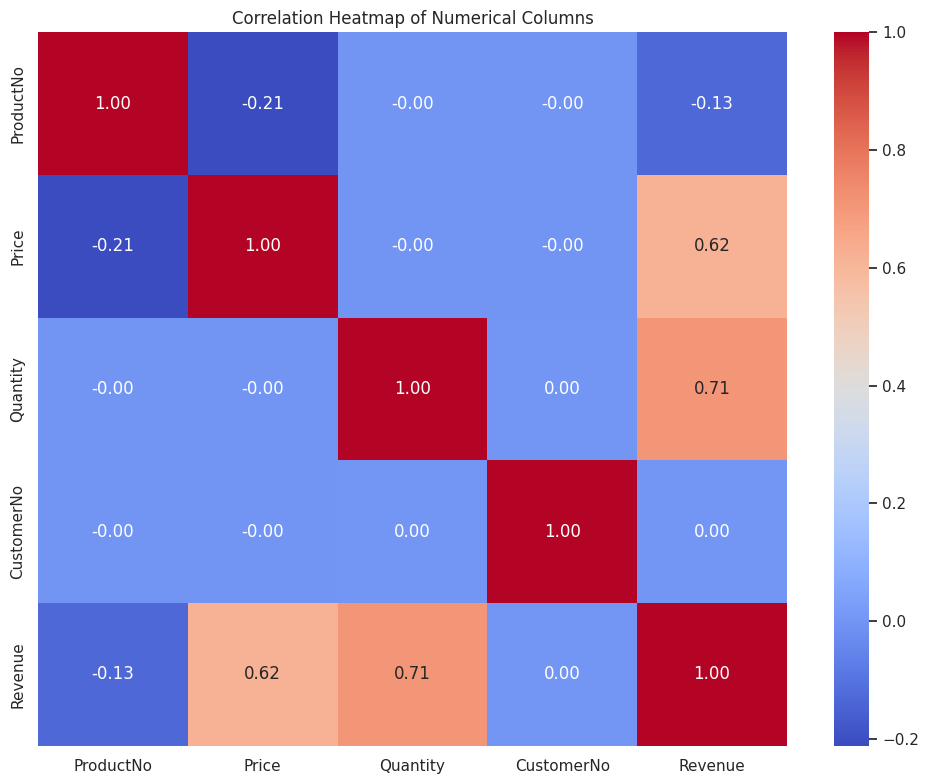

In [ ]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png')
plt.show()

Business insights

In [ ]:
## Business Insights from Data Analytics Report

Based on the performed data analysis and visualizations, here are 10 key business insights:

1.  **Dominant Product Category:** 'Home Accents' is by far the highest-grossing product category, generating almost double the revenue of the next category. This indicates a strong market position and potential for further investment in this area.
2.  **Stable Revenue Streams:** Both daily and monthly revenue trends show a relatively stable pattern with consistent fluctuations, suggesting predictable seasonal or monthly business cycles. There are no drastic dips or spikes that would indicate instability.
3.  **Consistent Customer Demand:** The monthly order count remains highly consistent throughout the analyzed period, which implies a steady customer base and stable demand for products.
4.  **High-Value Customer Identification:** Specific customer numbers have been identified as top revenue contributors. These high-value customers should be targeted with personalized marketing campaigns and loyalty programs to foster retention.
5.  **Strong Repeat Purchase Behavior:** The distribution of transactions per customer indicates that a significant portion of customers engage in repeat purchases (3-7 transactions), highlighting good customer loyalty and the effectiveness of current retention strategies.
6.  **Key International Markets:** Italy, USA, Switzerland, and Netherlands consistently appear among the top 10 countries by revenue, signaling these are crucial geographic markets for expansion or focused marketing efforts.
7.  **Top-Performing Products:** 'Glass Bowl Set' and 'Ceramic Vase' are the leading products by revenue, indicating their popularity and suggesting opportunities for cross-selling or up-selling related items.
8.  **Transaction Value Skew:** The distribution of transaction revenue shows a large number of smaller transactions, but a long tail reveals that a few high-value transactions also contribute substantially to overall revenue. Strategies could focus on increasing both frequency of small purchases and value of larger ones.
9.  **Direct Revenue Drivers:** The correlation heatmap confirms that both 'Price' and 'Quantity' are strongly positively correlated with 'Revenue', as expected. This underscores the importance of optimizing both pricing strategies and sales volume.
10. **Diverse Product Strategy:** The low correlation between 'Price' and 'Quantity' suggests a balanced product portfolio where some high-priced items sell in lower quantities, and some lower-priced items sell in higher quantities, both contributing effectively to the overall revenue. This diversified approach mitigates risk associated with reliance on a single pricing or volume strategy.